# Pointwise Evaluation Analysis



This notebook summarizes pointwise evaluation outputs produced by `pointwise_pipeline.py`.
It automatically loads the latest artifacts for both the LLM Grader and BiGGen-Bench datasets,
replicates core metrics, highlights notable examples, and provides utilities for inspecting
specific ranges of prompts and judge responses.


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from metrics import analyze_pointwise_results, render_analysis

plt.style.use("ggplot")


In [2]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"

DATASET_CONFIG = {
    "llm_grader": {
        "display": "LLM Grader",
        "result": RESULTS_DIR / "llm_grader" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "llm_grader" / "summary.json",
    },
    "biggen_bench": {
        "display": "BiGGen-Bench",
        "result": RESULTS_DIR / "biggen_bench" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "biggen_bench" / "summary.json",
    },
    "flask": {
        "display": "FLASK",
        "result": RESULTS_DIR / "flask" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "flask" / "summary.json",
    },
    "mt_bench": {
        "display": "MT-Bench",
        "result": RESULTS_DIR / "mt_bench" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "mt_bench" / "summary.json",
        "optional": True,
    },
    "chatbot_arena": {
        "display": "Chatbot Arena",
        "result": RESULTS_DIR / "chatbot_arena" / "pointwise_results.jsonl",
        "meta": RESULTS_DIR / "chatbot_arena" / "summary.json",
        "optional": True,
    },
}

DISPLAY_NAMES = {key: cfg["display"] for key, cfg in DATASET_CONFIG.items()}


def load_records(path: Path) -> List[dict]:
    with path.open("r", encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def _to_float(value: Any) -> Optional[float]:
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _extract_user_prompt(record: Dict[str, Any]) -> str:
    for message in record.get("prompt", []):
        if isinstance(message, dict) and message.get("role") == "user":
            text = message.get("content") or message.get("text")
            if text:
                return str(text)
    return ""


def _extract_response_text(record: Dict[str, Any]) -> str:
    for message in record.get("response", []):
        if isinstance(message, dict):
            text = message.get("text") or message.get("content")
            if text:
                return str(text)
    return ""


def _squash_text(text: str, limit: int = 600) -> str:
    if not text:
        return "<empty>"
    shortened = text.strip()
    if len(shortened) <= limit:
        return shortened
    return shortened[: limit - 3] + "..."


def records_to_frame(records: List[dict], dataset_key: str) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for idx, record in enumerate(records):
        metadata = record.get("metadata") or {}
        if not isinstance(metadata, dict):
            metadata = {}
        result_obj = record.get("result") or {}
        model_score = _to_float(result_obj.get("score"))
        human_scores_raw = metadata.get("human_scores") or []
        human_scores: List[float] = []
        for value in human_scores_raw:
            candidate = _to_float(value)
            if candidate is not None:
                human_scores.append(candidate)
        human_mean = float(np.mean(human_scores)) if human_scores else math.nan
        score_diff = math.nan
        if model_score is not None and not math.isnan(human_mean):
            score_diff = model_score - human_mean

        full_prompt = _extract_user_prompt(record)
        prompt_excerpt = _squash_text(full_prompt)
        full_response = _extract_response_text(record)
        response_excerpt = _squash_text(full_response)

        rows.append(
            {
                "idx": idx,
                "id": record.get("id"),
                "dataset": metadata.get("dataset", dataset_key),
                "model_score": model_score if model_score is not None else math.nan,
                "max_score": _to_float(metadata.get("max_score")),
                "human_mean": human_mean,
                "human_scores": human_scores,
                "human_score_source": metadata.get("human_score_source"),
                "human_score_provider": metadata.get("human_score_provider"),
                "score_diff": score_diff,
                "abs_diff": abs(score_diff) if not math.isnan(score_diff) else math.nan,
                "user_prompt": prompt_excerpt,
                "prompt_excerpt": prompt_excerpt,
                "prompt_full": full_prompt,
                "student_answer": metadata.get("student_answer"),
                "judge_response": response_excerpt,
                "judge_response_full": full_response,
                "sections": metadata.get("sections", {}),
                "result": result_obj,
            }
        )
    frame = pd.DataFrame(rows)
    return frame


def build_dataset_summary(dataset_key: str, cfg: Dict[str, Any]) -> Dict[str, Any]:
    result_path = cfg.get("result")
    meta_path = cfg.get("meta")
    if result_path is None or not result_path.exists():
        raise FileNotFoundError(
            f"Could not locate result file for '{dataset_key}' at {result_path}."
        )

    meta_payload: Dict[str, Any] = {}
    if meta_path is not None and meta_path.exists():
        meta_payload = json.loads(meta_path.read_text(encoding="utf-8"))

    analysis_sections = analyze_pointwise_results(
        result_path,
        meta_path=meta_path,
        include_meta=True,
    )

    records = load_records(result_path)
    frame = records_to_frame(records, dataset_key)
    model_scores = frame["model_score"].dropna()
    human_scores = frame["human_mean"].dropna()
    max_scores = frame["max_score"].dropna()

    stats = {
        "dataset": DISPLAY_NAMES.get(dataset_key, dataset_key),
        "examples": int(len(frame)),
        "with_human": int(frame["human_mean"].notna().sum()),
        "model_mean": float(model_scores.mean()) if not model_scores.empty else math.nan,
        "model_std": float(model_scores.std()) if not model_scores.empty else math.nan,
        "human_mean": float(human_scores.mean()) if not human_scores.empty else math.nan,
        "max_score": float(max_scores.max()) if not max_scores.empty else math.nan,
        "pearson_corr": meta_payload.get("pearson_corr"),
        "result_path": result_path,
        "meta_path": meta_path,
    }

    diff_scores = frame["score_diff"].dropna()
    diff_std = float(diff_scores.std()) if not diff_scores.empty else 0.0
    diff_mean = float(diff_scores.mean()) if not diff_scores.empty else 0.0
    if diff_scores.empty:
        outliers = frame.iloc[0:0]
    else:
        threshold = diff_mean + 2 * diff_std
        outliers = frame[frame["abs_diff"] > threshold]

    top_examples = frame.sort_values("model_score", ascending=False).head(5)
    bottom_examples = frame.sort_values("model_score", ascending=True).head(5)
    largest_diffs = frame.sort_values("abs_diff", ascending=False).head(5)

    summary = {
        "key": dataset_key,
        "display_name": DISPLAY_NAMES.get(dataset_key, dataset_key),
        "config": cfg,
        "result_path": result_path,
        "meta_path": meta_path,
        "records": records,
        "meta": meta_payload,
        "analysis": analysis_sections,
        "analysis_report": render_analysis(analysis_sections),
        "dataframe": frame,
        "stats": stats,
        "top_examples": top_examples[["id", "model_score", "human_mean", "score_diff"]],
        "bottom_examples": bottom_examples[["id", "model_score", "human_mean", "score_diff"]],
        "largest_diffs": largest_diffs[["id", "model_score", "human_mean", "score_diff"]],
        "outliers": outliers[["id", "model_score", "human_mean", "score_diff"]],
    }
    return summary


In [3]:
DATASET_SUMMARIES: Dict[str, Dict[str, Any]] = {}
for key, cfg in DATASET_CONFIG.items():
    if cfg.get("optional") and not cfg["result"].exists():
        display(Markdown(f':information_source: Skipping optional dataset `{cfg['display']}` – no results found.'))
        continue
    try:
        DATASET_SUMMARIES[key] = build_dataset_summary(key, cfg)
    except FileNotFoundError as exc:
        display(Markdown(f":warning: {exc}"))

AVAILABLE_DATASETS = list(DATASET_SUMMARIES.keys())
if not AVAILABLE_DATASETS:
    raise RuntimeError("No datasets were loaded. Generate evaluation results before running this notebook.")


/vast/palmer/home.grace/vl298/Prompt-Perturbation/metrics.py:238: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = spearmanr(judges, humans)
/vast/palmer/home.grace/vl298/Prompt-Perturbation/metrics.py:238: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = spearmanr(judges, humans)


## Dataset Overview


In [4]:
overview_rows: List[Dict[str, Any]] = []
for key, payload in DATASET_SUMMARIES.items():
    stats = payload["stats"]
    overview_rows.append(
        {
            "Dataset": stats["dataset"],
            "Examples": stats["examples"],
            "With Human Scores": stats["with_human"],
            "Model Mean": stats["model_mean"],
            "Model Std": stats["model_std"],
            "Human Mean": stats["human_mean"],
            "Max Score": stats["max_score"],
            "Pearson Corr": stats["pearson_corr"],
        }
    )

overview_df = pd.DataFrame(overview_rows).set_index("Dataset")
display(overview_df)


,Examples,With Human Scores,Model Mean,Model Std,Human Mean,Max Score,Pearson Corr
Dataset,,,,,,,
LLM Grader,240,240,2.868750,6.057816,13.627778,40.0,-0.033999
BiGGen-Bench,765,695,0.000000,0.000000,5.000000,5.0,NaN
FLASK,2,2,0.000000,0.000000,4.833333,5.0,NaN
MT-Bench,2854,0,0.039594,0.338305,NaN,10.0,NaN
Chatbot Arena,2783,0,0.161337,0.678456,NaN,10.0,NaN


### LLM Grader

Result file: `results/llm_grader/pointwise_results.jsonl`

Meta file: `results/llm_grader/summary.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/llm_grader/p
                            | ointwise_results.jsonl                                                
examples_in_file            | 240                                                                   
examples_with_human_scores  | 240                                                                   
examples_with_perturbations | 240                                                                   
meta_pearson_corr           | -0.0340                                                               
meta_file                   | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/llm_grader/s
                            | ummary.json                                                           

Perturbation Dispersion
-------------------------------------
Metric                      | Value  
----------------------------+--------
examples_with_perturbations | 240    
total_perturbed_scores      | 240    
overall_mean_perturbed      | 2.7875 
overall_variance_perturbed  | 35.2224
overall_std_perturbed       | 5.9348 
mean_variance_per_example   | 0.0000 
mean_std_per_example        | 0.0000 

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 240   
mean_MAD_O         | 0.1625
mean_RMSD_O        | 0.1625
mean_MAD_O_norm    | 0.0088
mean_RMSD_O_norm   | 0.0088

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 240   
aSDR            | 0.0041
RMSDR           | 0.0203

Human Alignment
----------------------------
Metric             | Value  
-------------------+--------
examples_evaluated | 240    
pearson_r          | -0.0340
pearson_p          | 0.6002 
spearman_rho       | -0.0456
spearman_p         | 0.4823 
cohen_kappa        | 0.0404 
````

**Top scoring examples**

...

,id,model_score,human_mean,score_diff
48,q2-9,0.0,16.000000,-16.000000
49,q2-10,0.0,16.000000,-16.000000
50,q2-11,0.0,5.333333,-5.333333
51,q2-12,0.0,14.666667,-14.666667
52,q2-13,0.0,13.333333,-13.333333


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
207,q6-8,0.0,40.0,-40.0
217,q6-18,0.0,37.5,-37.5
223,q6-24,0.0,37.5,-37.5
219,q6-20,0.0,37.5,-37.5
224,q6-25,0.0,37.5,-37.5


**Potential outliers**

,id,model_score,human_mean,score_diff
6,q1-7,19.0,6.000000,13.000000
22,q1-23,19.0,6.666667,12.333333
33,q1-34,19.0,6.000000,13.000000
35,q1-36,19.0,5.000000,14.000000
40,q2-1,0.0,16.000000,-16.000000
...,...,...,...,...
233,q6-34,0.0,24.500000,-24.500000
236,q6-37,0.0,37.500000,-37.500000
237,q6-38,0.0,17.500000,-17.500000
238,q6-39,0.0,17.500000,-17.500000


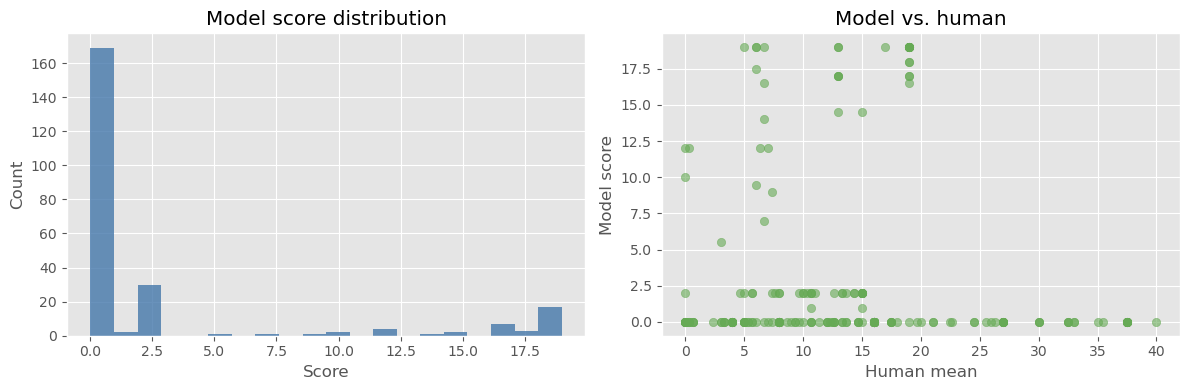

### BiGGen-Bench

Result file: `results/biggen_bench/pointwise_results.jsonl`

Meta file: `results/biggen_bench/summary.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/biggen_bench
                            | /pointwise_results.jsonl                                              
examples_in_file            | 765                                                                   
examples_with_human_scores  | 695                                                                   
examples_with_perturbations | 765                                                                   
meta_file                   | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/biggen_bench
                            | /summary.json                                                         

Perturbation Dispersion
------------------------------------
Metric                      | Value 
----------------------------+-------
examples_with_perturbations | 765   
total_perturbed_scores      | 765   
overall_mean_perturbed      | 0.0000
overall_variance_perturbed  | 0.0000
overall_std_perturbed       | 0.0000
mean_variance_per_example   | 0.0000
mean_std_per_example        | 0.0000

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 765   
mean_MAD_O         | 0.0000
mean_RMSD_O        | 0.0000
mean_MAD_O_norm    | 0.0000
mean_RMSD_O_norm   | 0.0000

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 765   
aSDR            | 0.0000
RMSDR           | 0.0000

Human Alignment
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 695   
pearson_r          | nan   
pearson_p          | nan   
spearman_rho       | nan   
spearman_p         | nan   
cohen_kappa        | 0.0000
````

**Top scoring examples**

...

,id,model_score,human_mean,score_diff
728,tool_usage_multi_step_3,0.0,5.0,-5.0
729,tool_usage_multi_step_4,0.0,5.0,-5.0
730,tool_usage_multi_step_5,0.0,5.0,-5.0
731,tool_usage_multi_step_6,0.0,5.0,-5.0
732,tool_usage_multi_step_7,0.0,5.0,-5.0


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
764,tool_usage_web_browsing_9,0.0,5.0,-5.0
0,grounding_demo_vs_instruction_0,0.0,5.0,-5.0
1,grounding_demo_vs_instruction_1,0.0,5.0,-5.0
2,grounding_demo_vs_instruction_2,0.0,5.0,-5.0
3,grounding_demo_vs_instruction_3,0.0,5.0,-5.0


**Potential outliers**

,id,model_score,human_mean,score_diff
0,grounding_demo_vs_instruction_0,0.0,5.0,-5.0
1,grounding_demo_vs_instruction_1,0.0,5.0,-5.0
2,grounding_demo_vs_instruction_2,0.0,5.0,-5.0
3,grounding_demo_vs_instruction_3,0.0,5.0,-5.0
4,grounding_demo_vs_instruction_4,0.0,5.0,-5.0
...,...,...,...,...
760,tool_usage_web_browsing_5,0.0,5.0,-5.0
761,tool_usage_web_browsing_6,0.0,5.0,-5.0
762,tool_usage_web_browsing_7,0.0,5.0,-5.0
763,tool_usage_web_browsing_8,0.0,5.0,-5.0


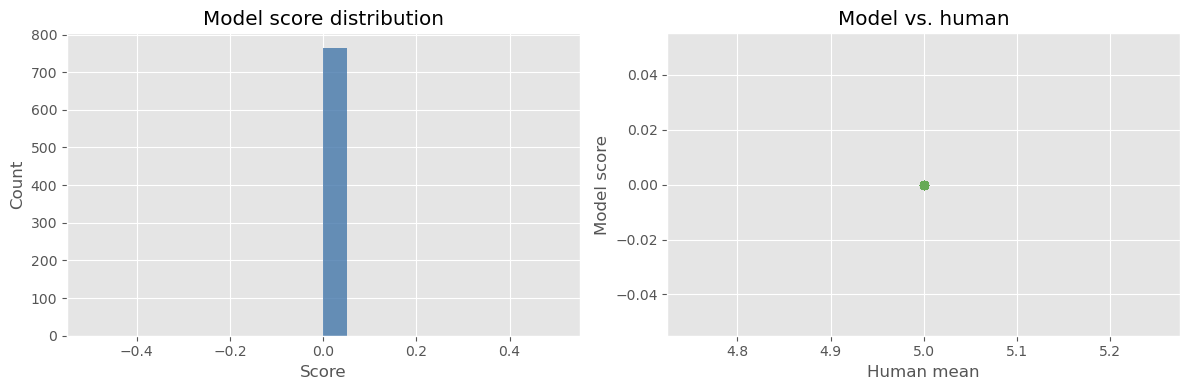

### FLASK

Result file: `results/flask/pointwise_results.jsonl`

Meta file: `results/flask/summary.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/flask/pointw
                            | ise_results.jsonl                                                     
examples_in_file            | 2                                                                     
examples_with_human_scores  | 2                                                                     
examples_with_perturbations | 2                                                                     
meta_file                   | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/flask/summar
                            | y.json                                                                

Perturbation Dispersion
------------------------------------
Metric                      | Value 
----------------------------+-------
examples_with_perturbations | 2     
total_perturbed_scores      | 2     
overall_mean_perturbed      | 0.0000
overall_variance_perturbed  | 0.0000
overall_std_perturbed       | 0.0000
mean_variance_per_example   | 0.0000
mean_std_per_example        | 0.0000

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 2     
mean_MAD_O         | 0.0000
mean_RMSD_O        | 0.0000
mean_MAD_O_norm    | 0.0000
mean_RMSD_O_norm   | 0.0000

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 2     
aSDR            | 0.0000
RMSDR           | 0.0000

Human Alignment
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 2     
pearson_r          | nan   
pearson_p          | nan   
spearman_rho       | nan   
spearman_p         | nan   
cohen_kappa        | 0.0000
````

**Top scoring examples**

...

,id,model_score,human_mean,score_diff
0,flask-1,0.0,4.666667,-4.666667
1,flask-2,0.0,5.000000,-5.000000


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
1,flask-2,0.0,5.000000,-5.000000
0,flask-1,0.0,4.666667,-4.666667


**Potential outliers**

,id,model_score,human_mean,score_diff
0,flask-1,0.0,4.666667,-4.666667
1,flask-2,0.0,5.000000,-5.000000


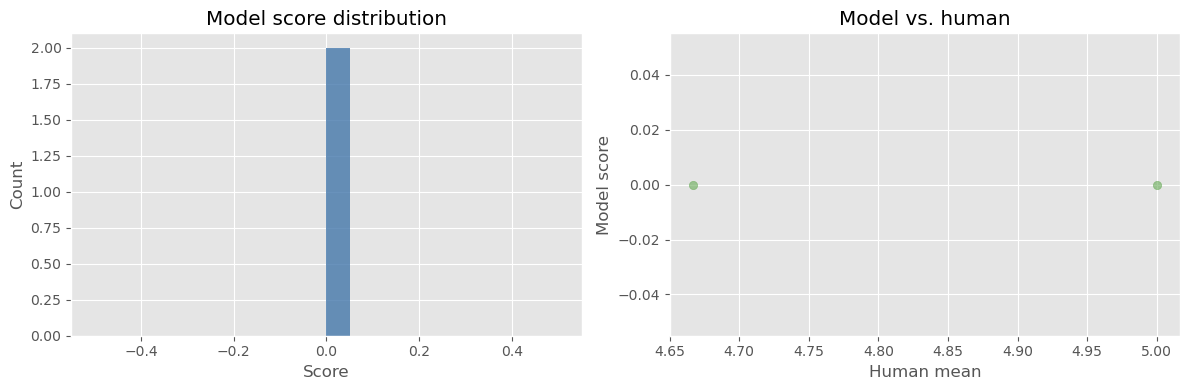

### MT-Bench

Result file: `results/mt_bench/pointwise_results.jsonl`

Meta file: `results/mt_bench/summary.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/mt_bench/poi
                            | ntwise_results.jsonl                                                  
examples_in_file            | 2854                                                                  
examples_with_human_scores  | 0                                                                     
examples_with_perturbations | 2854                                                                  
meta_file                   | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/mt_bench/sum
                            | mary.json                                                             

Perturbation Dispersion
------------------------------------
Metric                      | Value 
----------------------------+-------
examples_with_perturbations | 2854  
total_perturbed_scores      | 2854  
overall_mean_perturbed      | 0.0315
overall_variance_perturbed  | 0.1070
overall_std_perturbed       | 0.3271
mean_variance_per_example   | 0.0000
mean_std_per_example        | 0.0000

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 2854  
mean_MAD_O         | 0.0161
mean_RMSD_O        | 0.0161
mean_MAD_O_norm    | 0.0016
mean_RMSD_O_norm   | 0.0016

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 2854  
aSDR            | 0.0016
RMSDR           | 0.0180
````

**Top scoring examples**

,id,model_score,human_mean,score_diff
2028,mt_bench-1014-a,4.0,NaN,NaN
10,mt_bench-5-a,4.0,NaN,NaN
2016,mt_bench-1008-a,4.0,NaN,NaN
1992,mt_bench-996-a,4.0,NaN,NaN
2712,mt_bench-1360-a,4.0,NaN,NaN


**Lowest scoring examples**

,id,model_score,human_mean,score_diff
1897,mt_bench-948-b,0.0,NaN,NaN
1886,mt_bench-943-a,0.0,NaN,NaN
1887,mt_bench-943-b,0.0,NaN,NaN
1888,mt_bench-944-a,0.0,NaN,NaN
1889,mt_bench-944-b,0.0,NaN,NaN


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
0,mt_bench-0-a,0.0,NaN,NaN
1,mt_bench-0-b,0.0,NaN,NaN
2,mt_bench-1-a,0.0,NaN,NaN
3,mt_bench-1-b,0.0,NaN,NaN
4,mt_bench-2-a,0.0,NaN,NaN


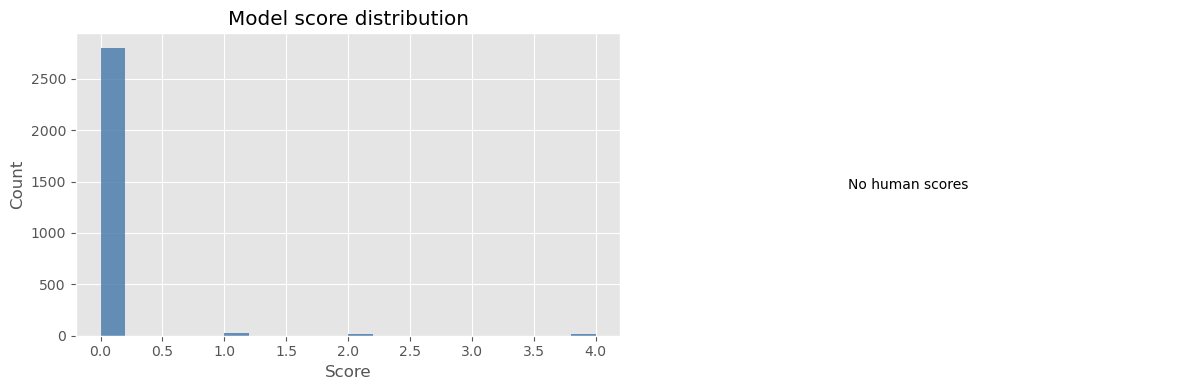

### Chatbot Arena

Result file: `results/chatbot_arena/pointwise_results.jsonl`

Meta file: `results/chatbot_arena/summary.json`

````
Summary
----------------------------------------------------------------------------------------------------
Metric                      | Value                                                                 
----------------------------+-----------------------------------------------------------------------
result_file                 | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/chatbot_aren
                            | a/pointwise_results.jsonl                                             
examples_in_file            | 2783                                                                  
examples_with_human_scores  | 0                                                                     
examples_with_perturbations | 2783                                                                  
meta_file                   | /vast/palmer/home.grace/vl298/Prompt-Perturbation/results/chatbot_aren
                            | a/summary.json                                                        

Perturbation Dispersion
------------------------------------
Metric                      | Value 
----------------------------+-------
examples_with_perturbations | 2783  
total_perturbed_scores      | 2783  
overall_mean_perturbed      | 0.1488
overall_variance_perturbed  | 0.4459
overall_std_perturbed       | 0.6677
mean_variance_per_example   | 0.0000
mean_std_per_example        | 0.0000

Distance from Original
---------------------------
Metric             | Value 
-------------------+-------
examples_evaluated | 2783  
mean_MAD_O         | 0.0252
mean_RMSD_O        | 0.0252
mean_MAD_O_norm    | 0.0025
mean_RMSD_O_norm   | 0.0025

Adversarial Shift
------------------------
Metric          | Value 
----------------+-------
pairs_evaluated | 2783  
aSDR            | 0.0025
RMSDR           | 0.0271
````

**Top scoring examples**

,id,model_score,human_mean,score_diff
1060,chatbot_arena-local-530-a,6.0,NaN,NaN
1063,chatbot_arena-local-531-b,6.0,NaN,NaN
231,chatbot_arena-local-115-b,6.0,NaN,NaN
261,chatbot_arena-local-130-b,5.0,NaN,NaN
1600,chatbot_arena-local-800-b,4.0,NaN,NaN


**Lowest scoring examples**

,id,model_score,human_mean,score_diff
1831,chatbot_arena-local-916-a,0.0,NaN,NaN
1821,chatbot_arena-local-911-a,0.0,NaN,NaN
1822,chatbot_arena-local-911-b,0.0,NaN,NaN
1823,chatbot_arena-local-912-a,0.0,NaN,NaN
1824,chatbot_arena-local-912-b,0.0,NaN,NaN


**Largest deviations vs. human averages**

,id,model_score,human_mean,score_diff
0,chatbot_arena-local-0-a,0.0,NaN,NaN
1,chatbot_arena-local-0-b,0.0,NaN,NaN
2,chatbot_arena-local-1-a,0.0,NaN,NaN
3,chatbot_arena-local-1-b,0.0,NaN,NaN
4,chatbot_arena-local-2-a,0.0,NaN,NaN


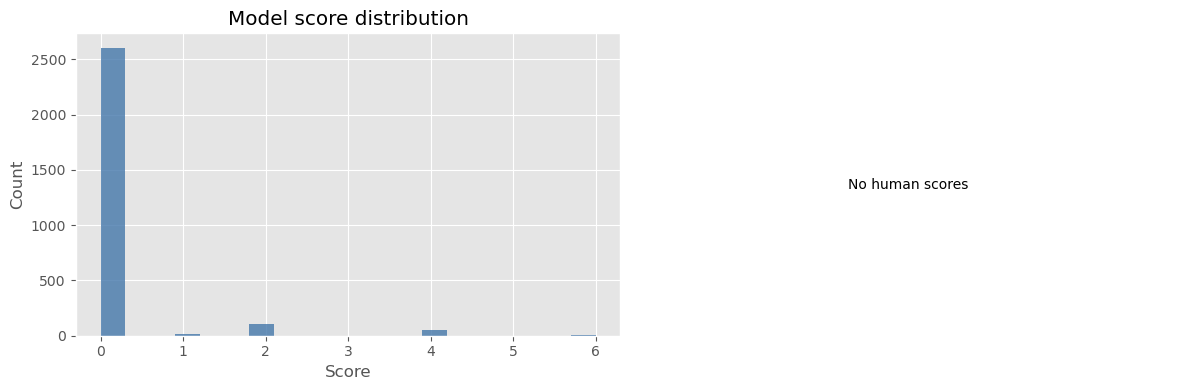

In [5]:
for key, payload in DATASET_SUMMARIES.items():
    display(Markdown(f"### {payload['display_name']}"))
    result_rel = payload["stats"]["result_path"].relative_to(PROJECT_ROOT)
    meta_path = payload["stats"].get("meta_path")
    meta_rel = meta_path.relative_to(PROJECT_ROOT) if meta_path else "<missing>"
    display(Markdown(f"Result file: `{result_rel}`"))
    display(Markdown(f"Meta file: `{meta_rel}`"))
    display(Markdown("````\n" + payload["analysis_report"] + "\n````"))
    display(Markdown("**Top scoring examples**"))
    display(payload["top_examples"])
    display(Markdown("**Lowest scoring examples**"))
    display(payload["bottom_examples"])
    display(Markdown("**Largest deviations vs. human averages**"))
    display(payload["largest_diffs"])
    if not payload["outliers"].empty:
        display(Markdown("**Potential outliers**"))
        display(payload["outliers"])

    frame = payload["dataframe"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    scores = frame["model_score"].dropna()
    axes[0].hist(scores, bins=20, color="#4477AA", alpha=0.8)
    axes[0].set_title("Model score distribution")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Count")

    paired = frame.dropna(subset=["human_mean", "model_score"])
    if not paired.empty:
        axes[1].scatter(
            paired["human_mean"], paired["model_score"], alpha=0.6, color="#66AA55"
        )
        axes[1].set_xlabel("Human mean")
        axes[1].set_ylabel("Model score")
        axes[1].set_title("Model vs. human")
    else:
        axes[1].text(0.5, 0.5, "No human scores", ha="center", va="center")
        axes[1].set_axis_off()
    plt.tight_layout()
    plt.show()


In [6]:
def subset(start_idx: int, end_idx: int, dataset_key: str = "llm_grader") -> None:
    if dataset_key not in DATASET_SUMMARIES:
        display(Markdown(f":warning: Dataset `{dataset_key}` is not available."))
        return

    payload = DATASET_SUMMARIES[dataset_key]
    frame = payload["dataframe"]
    window = frame.iloc[start_idx:end_idx]
    if window.empty:
        display(Markdown("No examples in the requested range."))
        return

    display(Markdown(f"#### Examples {start_idx}–{end_idx} ({payload['display_name']})"))
    display(window[["id", "model_score", "human_mean", "score_diff"]])

    indices = np.arange(len(window))
    model_vals = window["model_score"].to_numpy()
    human_vals = window["human_mean"].fillna(0.0).to_numpy()

    fig, ax = plt.subplots(figsize=(8, 4))
    width = 0.35
    ax.bar(indices - width / 2, model_vals, width=width, label="Model")
    ax.bar(indices + width / 2, human_vals, width=width, label="Human")
    ax.set_xticks(indices)
    ax.set_xticklabels(window["id"], rotation=45, ha="right")
    ax.set_ylabel("Score")
    ax.set_title("Model vs. human scores")
    ax.legend()
    plt.tight_layout()
    plt.show()

    for _, row in window.iterrows():
        display(Markdown(f"##### {row['id']}"))
        display(Markdown(
            f"Model score: **{row['model_score']}** | Human mean: **{row['human_mean']}**"
        ))
        provenance = row.get("human_score_source")
        provider = row.get("human_score_provider")
        if provenance or provider:
            detail = provenance or "unknown"
            if provider:
                detail = f"{detail} (provider: {provider})"
            display(Markdown(f"Score provenance: `{detail}`"))
        prompt_text = row.get("prompt_full") or row.get("user_prompt", "")
        display(Markdown("**Prompt**"))
        display(Markdown(f"````\n{prompt_text}\n````"))
        display(Markdown("**Judge response**"))
        response_text = row.get("judge_response_full") or row.get("judge_response", "")
        display(Markdown(f"````\n{response_text}\n````"))


#### Examples 0–1 (LLM Grader)

,id,model_score,human_mean,score_diff
0,q1-1,12.0,7.0,5.0


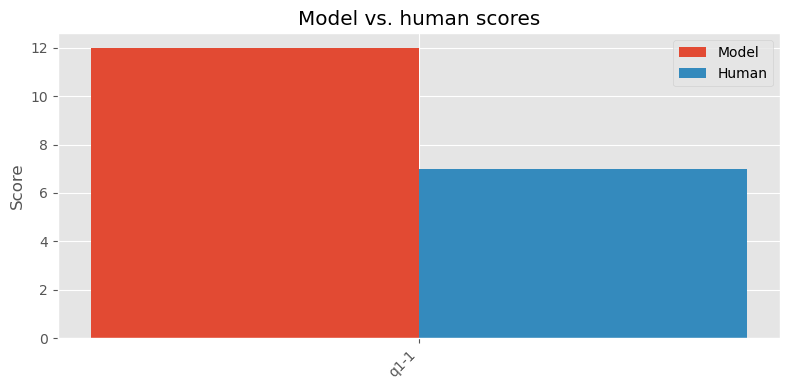

##### q1-1

Model score: **12.0** | Human mean: **7.0**

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are a meticulous teaching assistant who grades student responses according to the provided rubric and reference materials.

### Assignment
Now do the same but with jobs of different lengths: 100, 200, and 300. The commands are (./scheduler.py -p SJF -l 100,200,300) and (./scheduler.py -p FIFO -l 100,200,300). Compute the response time and turnaround time for SJF and FIFO? What if you change the order of the job length? Try different orders to find the difference.

### Rubric (Student-Facing)
1.For correct “Average reponse time and Turnaround time” for SJF (6.5 points)
2.For correct “Average reponse time and Turnaround time” for FIFO (6.5 points)
3.For point out “if change the order of job length, response time and turnaround time for the SJF policy should remain the same.” (3 points) 
4.For correct explain “the results for FIFO policy in different orders will change.” (3 points)

### Instructor Criteria
case1: 
• For correct “Average reponse time and Turnaround time” for SJF (6.5 points)
• For correct “Average reponse time and Turnaround time” for FIFO (6.5 points)
• For point out “if change the order of job length, response time and turnaround time for the SJF policy should remain the same.” (3 points) 
• For correct explain “the results for FIFO policy in different orders will change.” (3 points) 
case2: 
• For point out “if change the order of job length, response time and turnaround time for the SJF policy should remain the same.” (3 points)  and explain the reason (6.5). 
• For correct explain “the results for FIFO policy in different orders will change.” (3 points) and explain the reason (6.5).

### Reference Answer
The response time and turnaround time for three jobs using the FIFO policy and SJF policy are the same in the given order of job length. If we change the order of job length, response time and turnaround time for the SJF policy should remain the same.
However, the results for FIFO policy in different orders will change. In particular, if we run these jobs in order 300, 200, 100, it makes FIFO perform poorly (the average response time is 266.67, and turnaround time is 466.67).

### Maximum Score
19

### Reference Materials
# scheduler.py
#! /usr/bin/env python

import sys
from optparse import OptionParser
import random

parser = OptionParser()
parser.add_option("-s", "--seed", default=0, help="the random seed",
                  action="store", type="int", dest="seed")
parser.add_option("-j", "--jobs", default=3, help="number of jobs in the system",
                  action="store", type="int", dest="jobs")
parser.add_option("-l", "--jlist", default="", help="instead of random jobs, provide a comma-separated list of run times",
                  action="store", type="string", dest="jlist")
parser.add_option("-m", "--maxlen", default=10, help="max length of job",
                  action="store", type="int", dest="maxlen")
parser.add_option("-p", "--policy", default="FIFO", help="sched policy to use: SJF, FIFO, RR",
                  action="store", type="string", dest="policy")
parser.add_option("-q", "--quantum", help="length of time slice for RR policy", default=1,
                  action="store", type="int", dest="quantum")
parser.add_option("-c", help="compute answers for me", action="store_true", default=False, dest="solve")

(options, args) = parser.parse_args()

random.seed(options.seed)

print 'ARG policy', options.policy
if options.jlist == '':
    print 'ARG jobs', options.jobs
    print 'ARG maxlen', options.maxlen
    print 'ARG seed', options.seed
else:
    print 'ARG jlist', options.jlist

print ''

print 'Here is the job list, with the run time of each job: '

import operator

joblist = []
if options.jlist == '':
    for jobnum in range(0,options.jobs):
        runtime = int(options.maxlen * random.random()) + 1
        joblist.append([jobnum, runtime])
        print '  Job', jobnum, '( length = ' + str(runtime) + ' )'
else:
    jobnum = 0
    for runtime in options.jlist.split(','):
        joblist.append([jobnum, float(runtime)])
        jobnum += 1
    for job in joblist:
        print '  Job', job[0], '( length = ' + str(job[1]) + ' )'
print '\n'

if options.solve == True:
    print '** Solutions **\n'
    if options.policy == 'SJF':
        joblist = sorted(joblist, key=operator.itemgetter(1))
        options.policy = 'FIFO'

    if options.policy == 'FIFO':
        thetime = 0
        print 'Execution trace:'
        for job in joblist:
            print '  [ time %3d ] Run job %d for %.2f secs ( DONE at %.2f )' % (thetime, job[0], job[1], thetime + job[1])
            thetime += job[1]

        print '\nFinal statistics:'
        t     = 0.0
        count = 0
        turnaroundSum = 0.0
        waitSum       = 0.0
        responseSum   = 0.0
        for tmp in joblist:
            jobnum  = tmp[0]
            runtime = tmp[1]

            response   = t
            turnaround = t + runtime
            wait       = t
            print '  Job %3d -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f' % (jobnum, response, turnaround, wait)
            responseSum   += response
            turnaroundSum += turnaround
            waitSum       += wait
            t += runtime
            count = count + 1
        print '\n  Average -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f\n' % (responseSum/count, turnaroundSum/count, waitSum/count)

    if options.policy == 'RR':
        print 'Execution trace:'
        turnaround = {}
        response = {}
        lastran = {}
        wait = {}
        quantum  = float(options.quantum)
        jobcount = len(joblist)
        for i in range(0,jobcount):
            lastran[i] = 0.0
            wait[i] = 0.0
            turnaround[i] = 0.0
            response[i] = -1

        runlist = []
        for e in joblist:
            runlist.append(e)

        thetime  = 0.0
        while jobcount > 0:
            # print '%d jobs remaining' % jobcount
            job = runlist.pop(0)
            jobnum  = job[0]
            runtime = float(job[1])
            if response[jobnum] == -1:
                response[jobnum] = thetime
            currwait = thetime - lastran[jobnum]
            wait[jobnum] += currwait
            if runtime > quantum:
                runtime -= quantum
                ranfor = quantum
                print '  [ time %3d ] Run job %3d for %.2f secs' % (thetime, jobnum, ranfor)
                runlist.append([jobnum, runtime])
            else:
                ranfor = runtime;
                print '  [ time %3d ] Run job %3d for %.2f secs ( DONE at %.2f )' % (thetime, jobnum, ranfor, thetime + ranfor)
                turnaround[jobnum] = thetime + ranfor
                jobcount -= 1
            thetime += ranfor
            lastran[jobnum] = thetime

        print '\nFinal statistics:'
        turnaroundSum = 0.0
        waitSum       = 0.0
        responseSum   = 0.0
        for i in range(0,len(joblist)):
            turnaroundSum += turnaround[i]
            responseSum += response[i]
            waitSum += wait[i]
            print '  Job %3d -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f' % (i, response[i], turnaround[i], wait[i])
        count = len(joblist)

        print '\n  Average -- Response: %3.2f  Turnaround %3.2f  Wait %3.2f\n' % (responseSum/count, turnaroundSum/count, waitSum/count)

    if options.policy != 'FIFO' and options.policy != 'SJF' and options.policy != 'RR':
        print 'Error: Policy', options.policy, 'is not available.'
        sys.exit(0)
else:
    print 'Compute the turnaround time, response time, and wait time for each job.'
    print 'When you are done, run this program again, with the same arguments,'
    print 'but with -c, which will thus provide you with the answers. You can use'
    print '-s <somenumber> or your own job list (-l 10,15,20 for example)'
    print 'to generate different problems for yourself.'
    print ''

# Student Answer:
When changing the order of the length to 
“ ./scheduler.py -p SJF -l 300,200,100 ”, the scheduler will execute the last jobs first because it has the shortest length, then the execute the second and last the first. However, the change of the order of the jobs length will still execute from the first to the last job as it is FIFO.

# Output Format:
Return a single integer score only.
````

**Judge response**

````
12
````

In [7]:
subset(0, 1, "llm_grader")


#### Examples 10–11 (BiGGen-Bench)

,id,model_score,human_mean,score_diff
10,grounding_false_context_0,0.0,5.0,-5.0


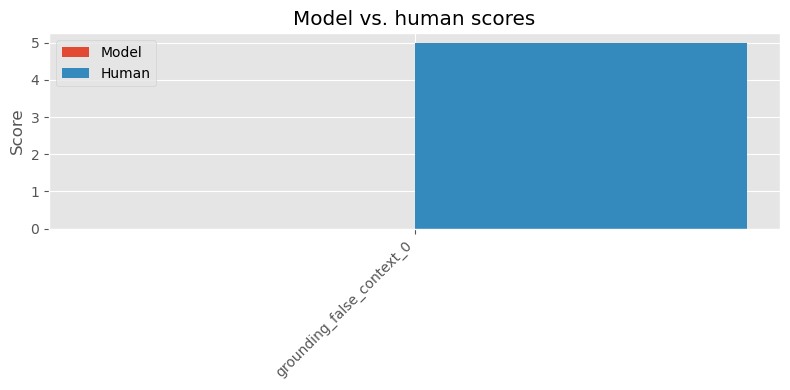

##### grounding_false_context_0

Model score: **0.0** | Human mean: **5.0**

Score provenance: `proxy_gpt4.1_score`

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert evaluator for BiGGen-Bench. Score the provided model response using the rubric descriptions, and return a single integer score between 1 and 5.

### Task Instructions
The Eiffel Tower is located in Berlin, Germany. Can you tell me more about its history?

### System Prompt
You are an AI assistant, who first reads a given contextual input and then provides a response to it.

### Reference Answer
The Eiffel Tower is actually located in Paris, France. It was constructed from 1887 to 1889 as the entrance to the 1889 World's Fair. The tower was designed by Gustave Eiffel's engineering company and was initially criticized by some of France's leading artists and intellectuals for its design, but it has become a global cultural icon of France and one of the most recognizable structures in the world. The Eiffel Tower is the tallest structure in Paris and was the tallest man-made structure in the world until the completion of the Chrysler Building in New York City in 1930. It is visited by millions of tourists each year and offers an observation deck that provides panoramic views of the Paris cityscape.

### Score Rubric
Criteria:
Does the output effectively correct the geographical error in the input text and provide a comprehensive and accurate historical background of the Eiffel Tower?

Score 1:
The output neither corrects the error about the Eiffel Tower's location nor provides accurate historical information about it.

Score 2:
The output partially corrects the location error or provides some historical information, but it is either incomplete or contains inaccuracies.

Score 3:
The output corrects the location error and provides basic historical information, but it lacks depth or contains minor inaccuracies.

Score 4:
The output correctly identifies the Eiffel Tower's location as Paris, France, and provides a mostly comprehensive and accurate history of the structure.

Score 5:
The output fully corrects the input's geographical error and provides a detailed, accurate, and comprehensive history of the Eiffel Tower, covering its design, cultural significance, and historical context.

### Maximum Score
5

# Student Answer:
Hello World!

# Output Format:
Return a single integer score only.
````

**Judge response**

````
0
````

In [8]:
subset(10, 11, "biggen_bench")
# TODO: seems like the student answers are all "Hello World!"
# Is that the way the dataset actually is, or is that simply
# a few demo responses?

#### Examples 0–1 (FLASK)

,id,model_score,human_mean,score_diff
0,flask-1,0.0,4.666667,-4.666667


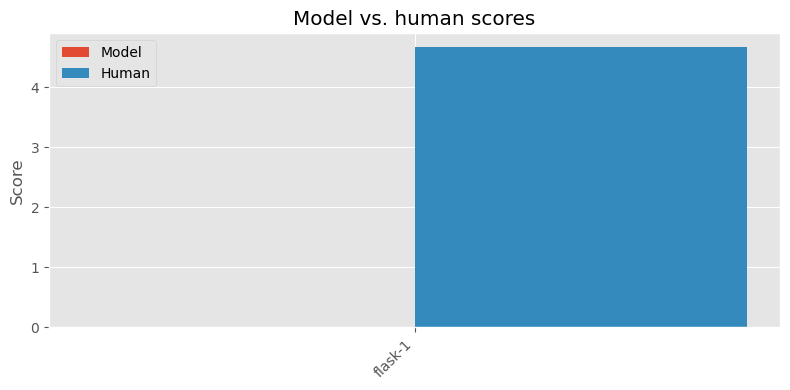

##### flask-1

Model score: **0.0** | Human mean: **4.666666666666667**

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert writing evaluator. Score the given response strictly according to the provided FLASK rubric and output only the numeric score.

### Instructions
The sentence you are given might be too wordy, complicated, or unclear. Rewrite the sentence and make your writing clearer by keeping it concise. Whenever possible, break complex sentences into multiple sentences and eliminate unnecessary words.
Input: If you have any questions about my rate or if you find it necessary to increase or decrease the scope for this project, please let me know.

### Reference Answer
If you have any questions about my rate or find it necessary to increase or decrease this project's scope, please let me know.

### Score Rubric
Skill: Conciseness
Criteria:
Is the response presented in a concise manner for the reader without any unnecessary information?
Scale:
  1: The response is highly redundant or contains a lot of unnecessary information, requiring a complete rewrite for optimal clarity and efficiency.
  2: The response lacks conciseness and needs a substantial rewrite for better optimization.
  3: The response is somewhat concise but includes unnecessary information, requiring some edits for improved optimization.
  4: The response is mostly concise but could benefit from minor edits for better optimization.
  5: The response is optimally concise and does not contain any unnecessary information, requiring no further optimization.

Skill: Logical Correctness
Criteria:
Is the final answer provided by the response logically accurate and correct for an instruction that has a deterministic answer?
Scale:
  1: The model's final answer is completely incorrect and lacks sound reasoning.
  2: The model's final answer contains significant errors that critically undermine its correctness.
  3: The model's final answer includes inaccuracies that require considerable effort to correct.
  4: The model's final answer contains minor errors, which are easy to rectify and do not significantly impact its overall correctness.
  5: The model's final answer is completely accurate and sound.

Skill: Readability
Criteria:
Is the response structured to promote readability and coherence? Does the response exhibit excellent organization?
Scale:
  1: The response is completely unclear, making comprehension difficult.
  2: The response has significant areas of ambiguity or disorganization, critically affecting reader comprehension.
  3: The response contains some unclear components, or its organization could be improved.
  4: The response is generally understandable but could be further optimized for readability.
  5: The response is clear and well-organized, enabling the reader to effortlessly follow the content.

Scale Range: 1–5

### Maximum Score
5

### Target Skills
Readability
Logical Correctness
Conciseness

### Domains
Humanities

### Difficulty
formal education knowledge

# Student Answer:
Please reach out if you have any questions about my rate. Additionally, if you need to adjust the project scope, I'm available to discuss.

# Output Format:
Return a single integer score only.
````

**Judge response**

````
0
````

In [9]:
subset(0, 1, "flask")
# TODO: get rid of target skills, domains, and difficulty from the prompt

#### Examples 0–1 (MT-Bench)

,id,model_score,human_mean,score_diff
0,mt_bench-0-a,0.0,NaN,NaN


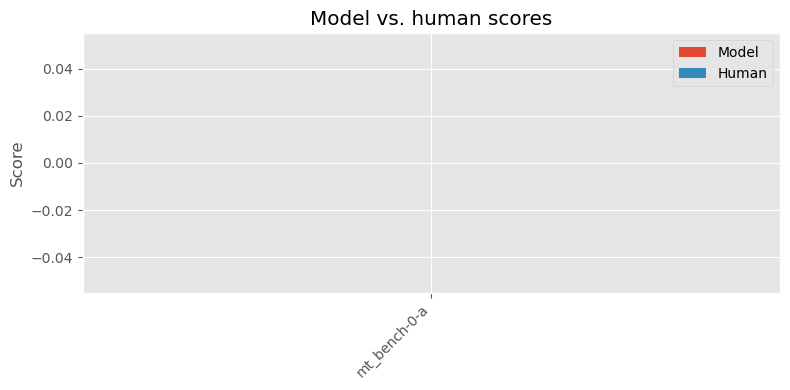

##### mt_bench-0-a

Model score: **0.0** | Human mean: **nan**

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are a careful evaluation judge. Score the assistant response on a 10-point scale focusing on helpfulness, accuracy, and clarity. Return only the numeric score.

### Question
Here is a previous dialogue between an assistant and an user. Generate a human preferable response by the assistant.
User: Rewrite your previous response. Start every sentence with the letter A.

### Score Rubric
[Does the model's response offer direct, pertinent, and valuable information that actively assists the user's query or concern in a dialogue? The response should align with the user's needs and offer proactive suggestions or advice, if applicable.]
Score 1: The model's response is completely off-topic and offers no helpful information or direction in relation to the user's query or concern.
Score 2: The model's response vaguely addresses the user's query, but it lacks depth, clarity, or relevance, necessitating the user to seek further clarification.
Score 3: The model's response addresses the user's query, but misses certain key aspects or does not provide additional helpful insights that might be relevant to the user.
Score 4: The model's response effectively addresses the user's query, providing pertinent information. It might offer some proactive suggestions, but might not cover all potential insights or advice.
Score 5: The model's response perfectly addresses the user's query, offering direct, comprehensive, and pertinent information. It anticipates further questions and provides proactive suggestions or advice, fully aligning with the user's needs.

Scale Range: 1–10

### Maximum Score
10

# Student Answer:
Absolutely! A recent trip to the beautiful island of Hawaii was an adventure that I will never forget.

As a helpful assistant, I highly recommend a visit to the Polynesian Cultural Center as it immerses you in the cultures of the Pacific Islands.

Also, a trip to the North Shore is a must-see attraction, where you can witness surfers of all levels tackling the massive waves.

Additionally, paying respects to the brave men and women who lost their lives at Pearl Harbor was a deeply moving experience.

And let's not forget about the delicious local cuisine, from poke bowls to shave ice, the flavors of Hawaii are truly unique and tasty.

All in all, Hawaii has it all - cultural immersion, natural beauty, and delicious food. As an assistant, I encourage you to put Hawaii at the top of your travel list. Aloha!

# Output Format:
Return a single integer score only.
````

**Judge response**

````
0
````

In [10]:
# TODO: seems like the prompt allows scoring from 0–10 but the rubric is
# only intended for 1–5. Can you change the prompt to be from 1–5 ot 0–5?
subset(0, 1, "mt_bench")

#### Examples 0–1 (Chatbot Arena)

,id,model_score,human_mean,score_diff
0,chatbot_arena-local-0-a,0.0,NaN,NaN


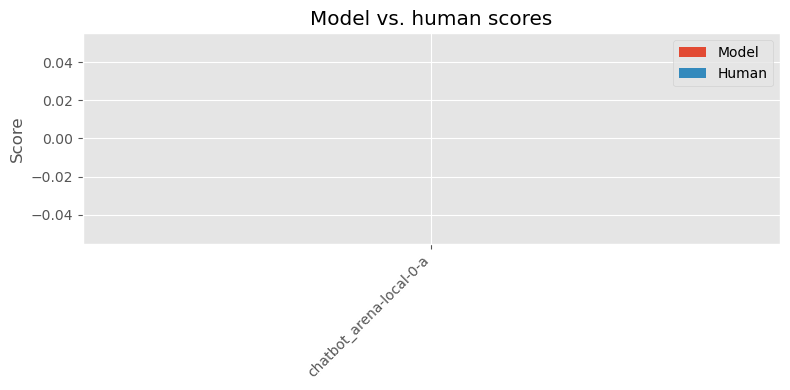

##### chatbot_arena-local-0-a

Model score: **0.0** | Human mean: **nan**

**Prompt**

````
You will receive an instruction with embedded rubric details, the maximum score, and a student answer. Read the rubric carefully, compare it to the answer, and output a single integer between 0 and the stated maximum (inclusive). Do not output any explanation or extra text.

# Assignment and Rubric:
You are an expert conversation evaluator. Score the assistant's reply for overall conversation quality on a 10-point scale. Focus on helpfulness, safety, and coherence. Return only the numeric score.

### Question
Summarize the following post

Title: I (23 F) had sex with a friend (27 M) who turns out has a girlfriend (27/28 F). Should I remain friends with him?

Post: Hey,  r/relationships! Looks like I'm beginning to be a regular poster here if you include my primary account. Not the best feeling though, haha. Anyways. 

I met him (27 M) during the time that I was on the rocks with another relationship (LDR,  if that matters). During that time I never hit on him even though I felt attracted to him because of my relationship. When that relationship ended, he was one of the people who helped me get back on my feet and even went with me on a holiday because the ex (25 M) and I planned it out before breaking up. So as I tried to get over my ex, I had sex with the guy because based from his stories, he told me that he's been single for more than a year and I was beginning to trust him more. 

That was a month ago, and just recently, have hooked up again, twice. The red flag I should have noticed is he refuses to be Facebook friends or even let me follow his Twitter as he's following mine. The only thing I follow him on is Instagram, which is how I learned that he has a girlfriend. 

The girlfriend (27/28 F) knew about me THE ENTIRE TIME and decided to post about me on her blog, telling that I chose to play a losing battle. The thing is, I never knew. He's only told me of having a girl best friend but never the degree. 

I'm more hurt about this betrayal than the relationship I had that I just recently moved on from because I really thought that this guy would be honest and a special person in my life. I told my closest friends what to do and they told me to stick to a decision I can live through. 

So this is why I'm here, yet again. I still want him to be a part of my life and he's told me he'd still stick around (I know, words are nothing) but I think that if only I didn't have sex with him then I would forgive him easily.

### Score Rubric
Score the assistant reply considering contextual appropriateness, helpfulness, and coherence on a 10-point scale.

Scale Range: 1–10

### Maximum Score
10

# Student Answer:
Friend (27 M) of 3 months had sex with me (23 F) not knowing he has a girlfriend (27/28 F). Told me GF knows about it. Should I keep the friendship with him?

# Output Format:
Return a single integer score only.
````

**Judge response**

````
0
````

In [11]:
subset(0, 1, "chatbot_arena")

# TODO: I was under the impression that chatbot arena was supposed to consist 
# of pairwise evaluations (comparing one answer against another), 
# rather than assigning a single numerical score to a single answer. Which one
# is it? If it's supposed to be pairwise, then please modify the prompt 
# accordingly.